# Method 1 — Pick-One-Out Statistical Analysis

Dataset: BPI Challenge 2017 (15,930 unique variants)
PM4Py Baseline: 0.9485 (computed on full log with Inductive Miner)

In [1]:
# Cell 1: Imports & Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Hardcoded from output/*_summary.json files
data = [
    # (Sampling, Miner, Pure, Joint, Variants, Runtime_s)
    ("2%",   "Alpha Miner",         0.3905, 0.3904,   319,     73.2),
    ("2%",   "Heuristics Miner",    0.9608, 0.9612,   319,    131.3),
    ("2%",   "Inductive Miner (IM)",  1.0000, 1.0000,   319,   1427.1),
    ("2%",   "Inductive Miner (IMf)", 0.9772, 0.9773,   319,   1068.9),
    ("10%",  "Alpha Miner",         0.3922, 0.3920,  1593,    238.2),
    ("10%",  "Heuristics Miner",    0.9594, 0.9598,  1593,    523.1),
    ("10%",  "Inductive Miner (IM)",  1.0000, 1.0000,  1593,   7229.4),
    ("10%",  "Inductive Miner (IMf)", 0.9776, 0.9777,  1593,   5479.2),
    ("20%",  "Alpha Miner",         0.3912, 0.3911,  3186,   1094.9),
    ("20%",  "Heuristics Miner",    0.9594, 0.9598,  3186,   2579.4),
    ("20%",  "Inductive Miner (IM)",  1.0000, 1.0000,  3186,  40968.9),
    ("20%",  "Inductive Miner (IMf)", 0.9773, 0.9774,  3186,  19086.2),
]

df = pd.DataFrame(data, columns=["Sampling", "Miner", "Pure", "Joint", "Variants", "Runtime_s"])
df["Gap"] = (df["Pure"] - df["Joint"]).abs()
df["Runtime_h"] = df["Runtime_s"] / 3600

BASELINE = 0.9485

df

,Sampling,Miner,Pure,Joint,Variants,Runtime_s,Gap,Runtime_h
0,2%,Alpha Miner,0.3905,0.3904,319,73.2,0.0001,0.020333
1,2%,Heuristics Miner,0.9608,0.9612,319,131.3,0.0004,0.036472
2,2%,Inductive Miner (IM),1.0000,1.0000,319,1427.1,0.0000,0.396417
3,2%,Inductive Miner (IMf),0.9772,0.9773,319,1068.9,0.0001,0.296917
4,10%,Alpha Miner,0.3922,0.3920,1593,238.2,0.0002,0.066167
5,10%,Heuristics Miner,0.9594,0.9598,1593,523.1,0.0004,0.145306
6,10%,Inductive Miner (IM),1.0000,1.0000,1593,7229.4,0.0000,2.008167
7,10%,Inductive Miner (IMf),0.9776,0.9777,1593,5479.2,0.0001,1.522000
8,20%,Alpha Miner,0.3912,0.3911,3186,1094.9,0.0001,0.304139
9,20%,Heuristics Miner,0.9594,0.9598,3186,2579.4,0.0004,0.716500


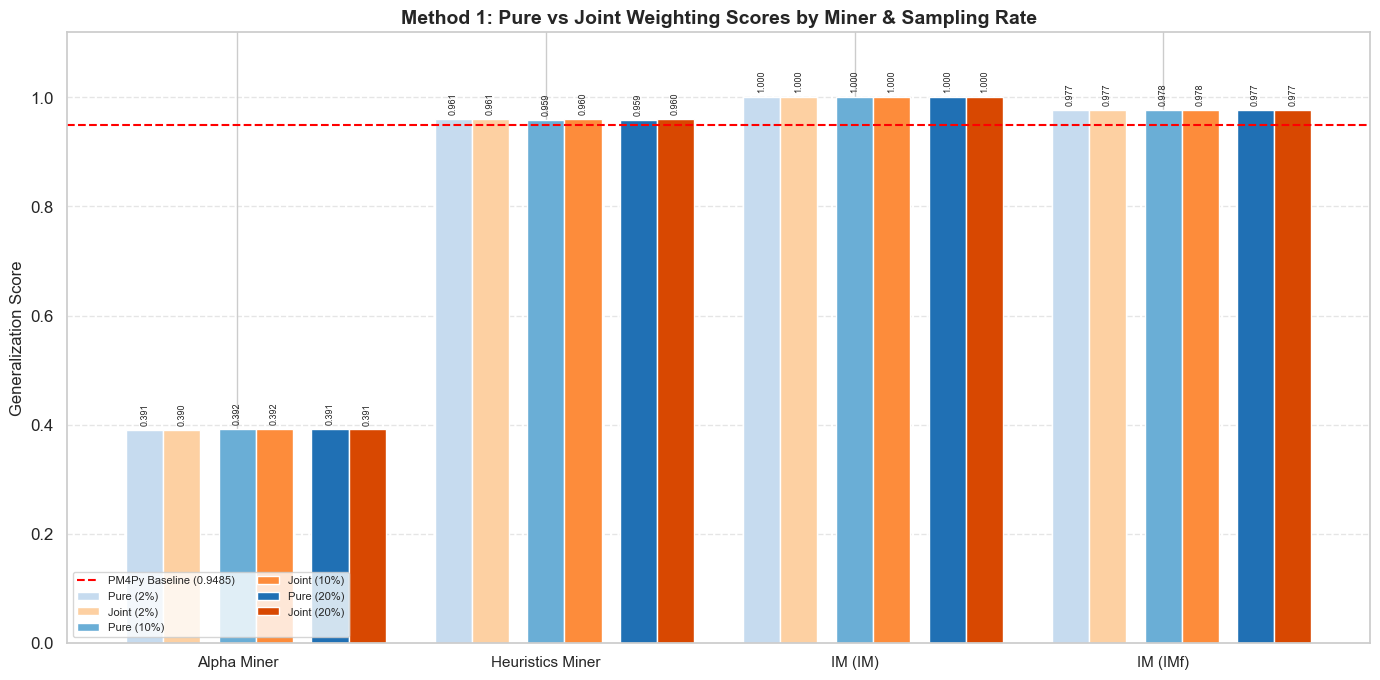

In [2]:
# Cell 2: Grouped Bar Chart — Pure vs Joint by Miner & Sampling Rate

fig, ax = plt.subplots(figsize=(14, 7))

miners = df["Miner"].unique()
samplings = ["2%", "10%", "20%"]
colors_pure = sns.color_palette("Blues", n_colors=3)
colors_joint = sns.color_palette("Oranges", n_colors=3)

x = np.arange(len(miners))
bar_width = 0.12

for i, samp in enumerate(samplings):
    sub = df[df["Sampling"] == samp].set_index("Miner")
    offset = (i - 1) * bar_width * 2.5
    bars_p = ax.bar(x + offset, [sub.loc[m, "Pure"] for m in miners],
                     bar_width, label=f"Pure ({samp})", color=colors_pure[i], edgecolor="white")
    bars_j = ax.bar(x + offset + bar_width, [sub.loc[m, "Joint"] for m in miners],
                     bar_width, label=f"Joint ({samp})", color=colors_joint[i], edgecolor="white")
    # Annotate
    for bar in bars_p:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=6.5, rotation=90)
    for bar in bars_j:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f"{h:.3f}",
                ha="center", va="bottom", fontsize=6.5, rotation=90)

# PM4Py baseline line
ax.axhline(y=BASELINE, color="red", linestyle="--", linewidth=1.5, label=f"PM4Py Baseline ({BASELINE})")

ax.set_xticks(x)
ax.set_xticklabels([m.replace("Inductive Miner", "IM") for m in miners], fontsize=11)
ax.set_ylabel("Generalization Score", fontsize=12)
ax.set_title("Method 1: Pure vs Joint Weighting Scores by Miner & Sampling Rate", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", ncol=2, fontsize=8)
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

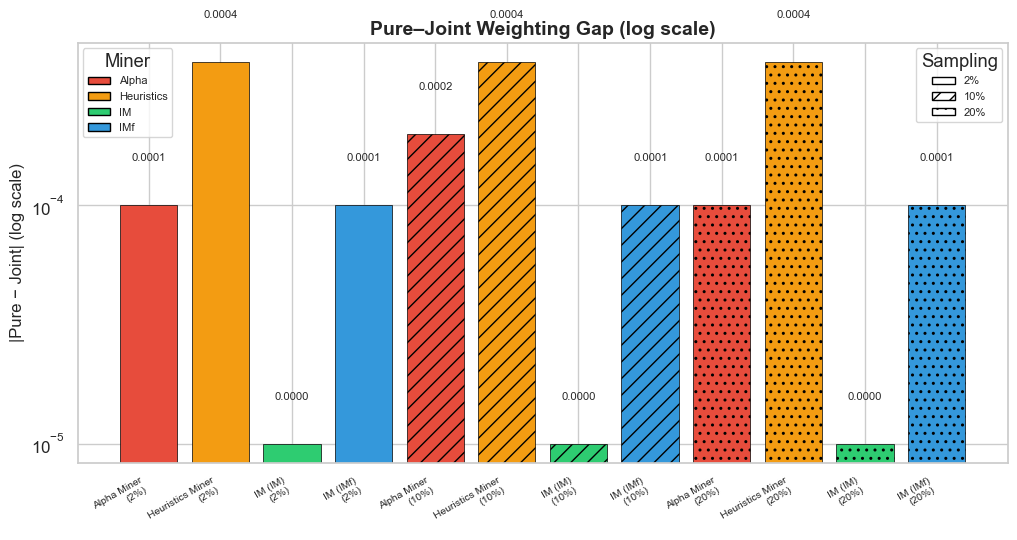

In [8]:
# Cell 3: Pure–Joint Gap — Bar Chart with Log Scale

fig, ax = plt.subplots(figsize=(12, 6))

gap_colors = {"Alpha Miner": "#E74C3C", "Heuristics Miner": "#F39C12",
              "Inductive Miner (IM)": "#2ECC71", "Inductive Miner (IMf)": "#3498DB"}
sampling_hatches = {"2%": "", "10%": "//", "20%": ".."}

# Use a small floor for log visibility (IM has 0.0000 gap)
gap_plot = df["Gap"].copy()
eps = 1e-5
gap_plot = gap_plot.clip(lower=eps)

x = np.arange(len(df))
bars = ax.bar(x, gap_plot, color=[gap_colors[m] for m in df["Miner"]],
              edgecolor="black", linewidth=0.5)

# Apply hatches
for bar, samp in zip(bars, df["Sampling"]):
    bar.set_hatch(sampling_hatches[samp])

# Annotate with actual gap values
for i, (bar, gap) in enumerate(zip(bars, df["Gap"])):
    label_y = max(gap, eps) * 1.5
    ax.text(bar.get_x() + bar.get_width() / 2, label_y,
            f"{gap:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Miner'].replace('Inductive Miner', 'IM')}\n({r['Sampling']})"
                     for _, r in df.iterrows()], fontsize=7.5, rotation=30, ha="right")
ax.set_ylabel("|Pure − Joint| (log scale)", fontsize=12)
ax.set_title("Pure–Joint Weighting Gap (log scale)", fontsize=14, fontweight="bold")

# Legend: colored by miner + hatched by sampling rate
from matplotlib.patches import Patch
miner_short = {"Alpha Miner": "Alpha", "Heuristics Miner": "Heuristics",
               "Inductive Miner (IM)": "IM", "Inductive Miner (IMf)": "IMf"}
legend_miners = [Patch(facecolor=gap_colors[m], edgecolor="black", label=miner_short[m])
                 for m in gap_colors]
legend_sampling = [Patch(facecolor="white", edgecolor="black", hatch=h, label=s)
                   for s, h in sampling_hatches.items()]

legend1 = ax.legend(handles=legend_miners, title="Miner", loc="upper left", fontsize=8)
ax.add_artist(legend1)
ax.legend(handles=legend_sampling, title="Sampling", loc="upper right", fontsize=8)

fig.subplots_adjust(bottom=0.18)
plt.show()

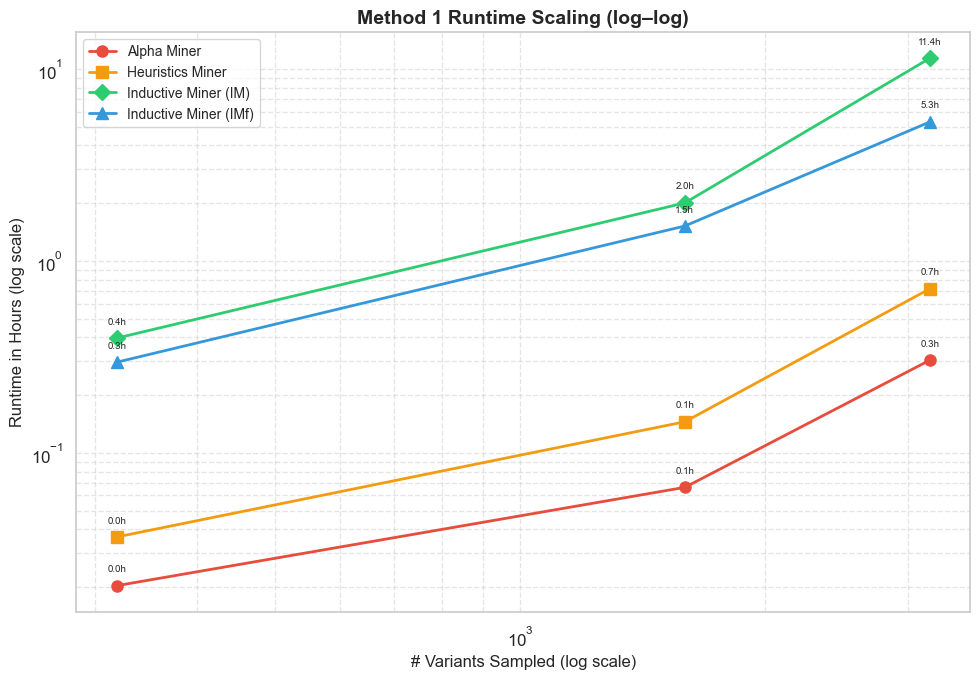

In [4]:
# Cell 4: Runtime Scaling — Log–Log Line Plot

fig, ax = plt.subplots(figsize=(10, 7))

miner_colors = {"Alpha Miner": "#E74C3C", "Heuristics Miner": "#F39C12",
                "Inductive Miner (IM)": "#2ECC71", "Inductive Miner (IMf)": "#3498DB"}
miner_markers = {"Alpha Miner": "o", "Heuristics Miner": "s",
                 "Inductive Miner (IM)": "D", "Inductive Miner (IMf)": "^"}

for miner in df["Miner"].unique():
    sub = df[df["Miner"] == miner].sort_values("Variants")
    ax.plot(sub["Variants"], sub["Runtime_h"], marker=miner_markers[miner],
            color=miner_colors[miner], linewidth=2, markersize=8, label=miner)
    # Annotate each point
    for _, row in sub.iterrows():
        ax.annotate(f"{row['Runtime_h']:.1f}h", (row["Variants"], row["Runtime_h"]),
                    textcoords="offset points", xytext=(0, 10), fontsize=7, ha="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("# Variants Sampled (log scale)", fontsize=12)
ax.set_ylabel("Runtime in Hours (log scale)", fontsize=12)
ax.set_title("Method 1 Runtime Scaling (log–log)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5, which="both")

plt.tight_layout()
plt.show()

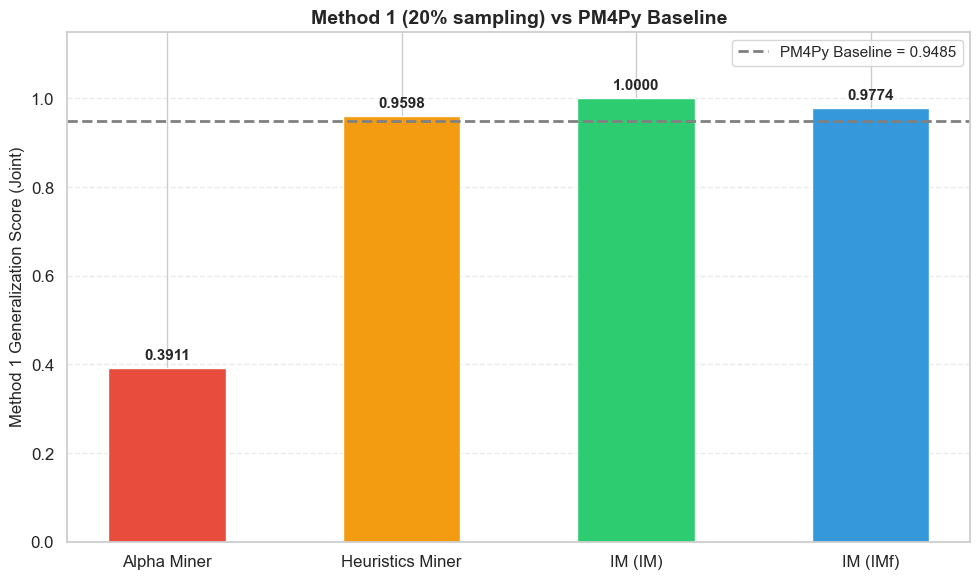

In [5]:
# Cell 5: Method 1 vs PM4Py Baseline — Per-Miner Comparison (20% sampling)

fig, ax = plt.subplots(figsize=(10, 6))

df20 = df[df["Sampling"] == "20%"].copy()
miners_short = [m.replace("Inductive Miner", "IM") for m in df20["Miner"]]
joint_scores = df20["Joint"].values

bar_colors = ["#E74C3C", "#F39C12", "#2ECC71", "#3498DB"]
bars = ax.bar(miners_short, joint_scores, color=bar_colors, edgecolor="white", width=0.5)

ax.axhline(y=BASELINE, color="gray", linestyle="--", linewidth=2, label=f"PM4Py Baseline = {BASELINE}")

for bar, score in zip(bars, joint_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{score:.4f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Method 1 Generalization Score (Joint)", fontsize=12)
ax.set_title("Method 1 (20% sampling) vs PM4Py Baseline", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

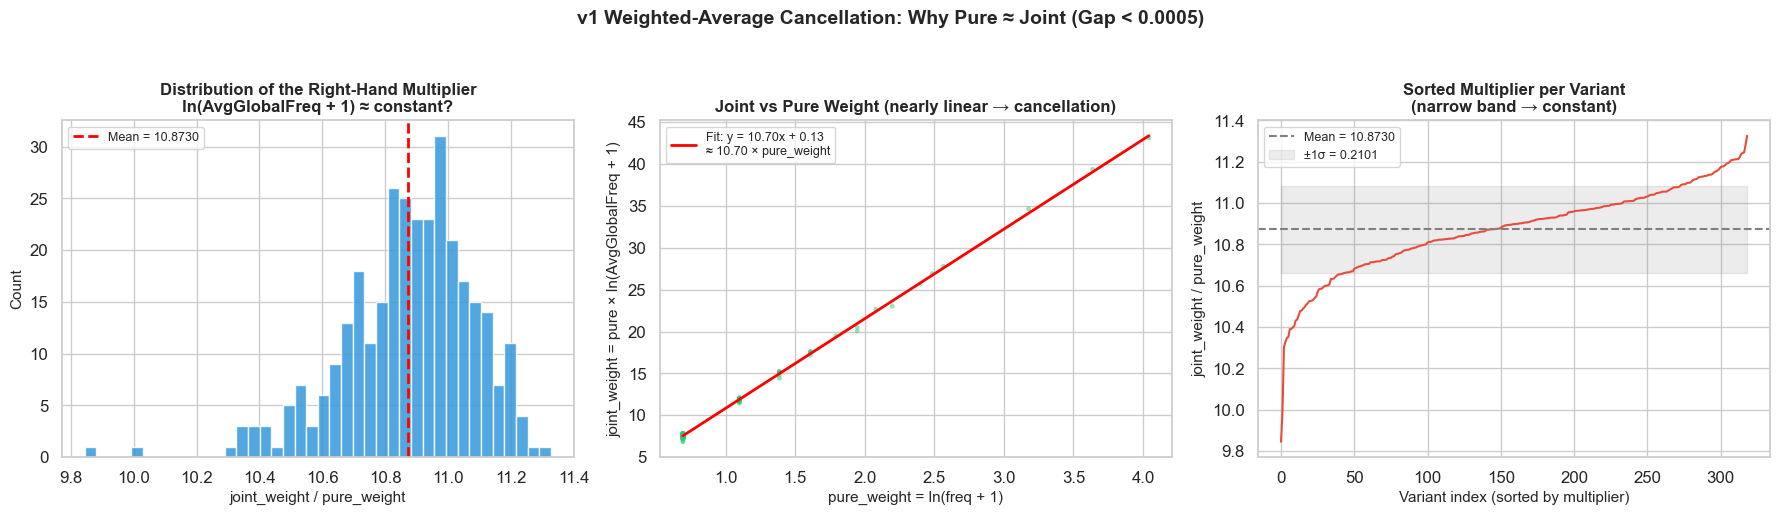

Multiplier stats:  mean = 10.8730,  std = 0.2101,  min = 9.8448,  max = 11.3262
Coefficient of variation = 1.9320%

→ Because the multiplier is nearly constant, it factors out of the weighted average.
→ Pure and Joint scores converge → the joint weighting component is neutralized.


In [9]:
# Cell 6: Visualizing the v1 Weighted-Average Cancellation
# v1 formula: w(v) = ln(freq + 1) × ln(AvgGlobalFreq + 1)
# If ln(AvgGlobalFreq + 1) ≈ constant k, then joint_weight ≈ k × pure_weight
# → k factors out of the weighted average → Pure ≈ Joint (gap < 0.0005)

import json

# Load detailed per-variant data from one run (Alpha 2%)
with open("output/method1_Alpha_2pct_20260512_152257_details.json") as f:
    detail = json.load(f)

variants = detail["detailed_results"][0]["results"]
pure_w = [v["pure_weight"] for v in variants]
joint_w = [v["joint_weight"] for v in variants]
multiplier = [j / p for j, p in zip(joint_w, pure_w)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Subplot 1: Histogram of the multiplier ──
ax1 = axes[0]
ax1.hist(multiplier, bins=40, color="#3498DB", edgecolor="white", alpha=0.85)
ax1.axvline(x=np.mean(multiplier), color="red", linestyle="--", linewidth=2,
            label=f"Mean = {np.mean(multiplier):.4f}")
ax1.set_xlabel("joint_weight / pure_weight", fontsize=11)
ax1.set_ylabel("Count", fontsize=11)
ax1.set_title("Distribution of the Right-Hand Multiplier\nln(AvgGlobalFreq + 1) ≈ constant?", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)

# ── Subplot 2: Scatter — joint_weight vs pure_weight ──
ax2 = axes[1]
ax2.scatter(pure_w, joint_w, alpha=0.5, s=12, color="#2ECC71", edgecolors="none")
# Linear fit to show near-perfect proportionality
m, b = np.polyfit(pure_w, joint_w, 1)
x_fit = np.linspace(min(pure_w), max(pure_w), 100)
ax2.plot(x_fit, m * x_fit + b, color="red", linewidth=2,
         label=f"Fit: y = {m:.2f}x + {b:.2f}\n≈ {m:.2f} × pure_weight")
ax2.set_xlabel("pure_weight = ln(freq + 1)", fontsize=11)
ax2.set_ylabel("joint_weight = pure × ln(AvgGlobalFreq + 1)", fontsize=11)
ax2.set_title("Joint vs Pure Weight (nearly linear → cancellation)", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)

# ── Subplot 3: Per-variant multiplier sorted ──
ax3 = axes[2]
sorted_mult = sorted(multiplier)
ax3.plot(sorted_mult, color="#E74C3C", linewidth=1.5)
ax3.axhline(y=np.mean(multiplier), color="gray", linestyle="--", linewidth=1.5,
            label=f"Mean = {np.mean(multiplier):.4f}")
ax3.fill_between(range(len(sorted_mult)),
                  np.mean(multiplier) - np.std(multiplier),
                  np.mean(multiplier) + np.std(multiplier),
                  alpha=0.15, color="gray", label=f"±1σ = {np.std(multiplier):.4f}")
ax3.set_xlabel("Variant index (sorted by multiplier)", fontsize=11)
ax3.set_ylabel("joint_weight / pure_weight", fontsize=11)
ax3.set_title("Sorted Multiplier per Variant\n(narrow band → constant)", fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)

plt.suptitle("v1 Weighted-Average Cancellation: Why Pure ≈ Joint (Gap < 0.0005)",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Multiplier stats:  mean = {np.mean(multiplier):.4f},  "
      f"std = {np.std(multiplier):.4f},  "
      f"min = {np.min(multiplier):.4f},  "
      f"max = {np.max(multiplier):.4f}")
print(f"Coefficient of variation = {np.std(multiplier) / np.mean(multiplier):.4%}")
print(f"\n→ Because the multiplier is nearly constant, it factors out of the weighted average.")
print(f"→ Pure and Joint scores converge → the joint weighting component is neutralized.")